**This program aims to predict future energy usage using a publicly available dataset**

In this case, the data has already been split into training & test data

**Load & Analyse Data**

Using pandas, load the data & inspect the first few rows

In [55]:
import pandas as pd

# Training data
train_df = pd.read_csv("train.csv")
print("Training data")
print(train_df.head())

# Test data
test_df = pd.read_csv("test.csv")
print("\nTest data")
print(test_df.head())


Training data
         date  power_consumption  year  semester  quarter day_in_week  \
0  12/16/2006           1209.176  2006         2        4         Sat   
1  12/17/2006           3390.460  2006         2        4         Sun   
2  12/18/2006           2203.826  2006         2        4         Mon   
3  12/19/2006           1666.194  2006         2        4         Tue   
4  12/20/2006           2225.748  2006         2        4         Wed   

   week_in_year  day_in_year  month  
0            50          350     12  
1            51          351     12  
2            51          352     12  
3            51          353     12  
4            51          354     12  

Test data
       date  power_consumption  year  semester  quarter day_in_week  \
0  4/1/2010           1687.440  2010         1        2         Thu   
1  4/2/2010           1648.622  2010         1        2         Fri   
2  4/3/2010           1805.278  2010         1        2         Sat   
3  4/4/2010           16

Check for any missing values

In [56]:
# Training data
print("Missing values in training data")
print(train_df.isnull().sum())

# Test data
print("\nMissing values in test data")
print(test_df.isnull().sum())

Missing values in training data
date                 0
power_consumption    0
year                 0
semester             0
quarter              0
day_in_week          0
week_in_year         0
day_in_year          0
month                0
dtype: int64

Missing values in test data
date                 0
power_consumption    0
year                 0
semester             0
quarter              0
day_in_week          0
week_in_year         0
day_in_year          0
month                0
dtype: int64


**Data Preparation**
Check the data types of each column

In [57]:
# Training data
print("Training data types")
print(train_df.dtypes)

# Test data
print("\nTest data types")
print(test_df.dtypes)

Training data types
date                  object
power_consumption    float64
year                   int64
semester               int64
quarter                int64
day_in_week           object
week_in_year           int64
day_in_year            int64
month                  int64
dtype: object

Test data types
date                  object
power_consumption    float64
year                   int64
semester               int64
quarter                int64
day_in_week           object
week_in_year           int64
day_in_year            int64
month                  int64
dtype: object


Convert *date* into a usable format

In [58]:
# Training data
train_df["date"] = pd.to_datetime(train_df["date"], format="%m/%d/%Y")
print("Training date format updated")
print(train_df.head())

# Test data
test_df["date"] = pd.to_datetime(test_df["date"], format="%m/%d/%Y")
print("\nTest date format updated")
print(test_df.head())

Training date format updated
        date  power_consumption  year  semester  quarter day_in_week  \
0 2006-12-16           1209.176  2006         2        4         Sat   
1 2006-12-17           3390.460  2006         2        4         Sun   
2 2006-12-18           2203.826  2006         2        4         Mon   
3 2006-12-19           1666.194  2006         2        4         Tue   
4 2006-12-20           2225.748  2006         2        4         Wed   

   week_in_year  day_in_year  month  
0            50          350     12  
1            51          351     12  
2            51          352     12  
3            51          353     12  
4            51          354     12  

Test date format updated
        date  power_consumption  year  semester  quarter day_in_week  \
0 2010-04-01           1687.440  2010         1        2         Thu   
1 2010-04-02           1648.622  2010         1        2         Fri   
2 2010-04-03           1805.278  2010         1        2         Sat

Convert *day_in_week* into a usable format (where 0 is Monday, 6 is Sunday) using numpy dt

In [59]:
# Training data
train_df["day_in_week"] = train_df["date"].dt.dayofweek
print("Training day in week format updated")
print(train_df.head())

# Test data
test_df["day_in_week"] = test_df["date"].dt.dayofweek
print("\nTest day of week format updated")
print(test_df.head())

Training day in week format updated
        date  power_consumption  year  semester  quarter  day_in_week  \
0 2006-12-16           1209.176  2006         2        4            5   
1 2006-12-17           3390.460  2006         2        4            6   
2 2006-12-18           2203.826  2006         2        4            0   
3 2006-12-19           1666.194  2006         2        4            1   
4 2006-12-20           2225.748  2006         2        4            2   

   week_in_year  day_in_year  month  
0            50          350     12  
1            51          351     12  
2            51          352     12  
3            51          353     12  
4            51          354     12  

Test day of week format updated
        date  power_consumption  year  semester  quarter  day_in_week  \
0 2010-04-01           1687.440  2010         1        2            3   
1 2010-04-02           1648.622  2010         1        2            4   
2 2010-04-03           1805.278  2010        

In [60]:
print(train_df.dtypes)
print(test_df.dtypes)

date                 datetime64[ns]
power_consumption           float64
year                          int64
semester                      int64
quarter                       int64
day_in_week                   int32
week_in_year                  int64
day_in_year                   int64
month                         int64
dtype: object
date                 datetime64[ns]
power_consumption           float64
year                          int64
semester                      int64
quarter                       int64
day_in_week                   int32
week_in_year                  int64
day_in_year                   int64
month                         int64
dtype: object


Cyclically encode *day in week* to avoid models inferring incorrect relationships (i.e. make sure it recognises Monday is after Sunday and the cycle continues)

In [61]:
import numpy as np

# Ensure values are numeric
train_df["day_in_week"] = pd.to_numeric(train_df["day_in_week"])
test_df["day_in_week"] = pd.to_numeric(test_df["day_in_week"])

# Training data
train_df["day_in_week_sin"] = np.sin(2 * np.pi * train_df["day_in_week"] / 7)
train_df["day_in_week_cos"] = np.cos(2 * np.pi * train_df["day_in_week"] / 7)

# Test data
test_df["day_in_week_sin"] = np.sin(2 * np.pi * test_df["day_in_week"] / 7)
test_df["day_in_week_cos"] = np.cos(2 * np.pi * test_df["day_in_week"] / 7)

# drop the original day_in_week column
train_df = train_df.drop(columns=["day_in_week"])
test_df = test_df.drop(columns=["day_in_week"])

print(train_df.head())
print(test_df.head())

        date  power_consumption  year  semester  quarter  week_in_year  \
0 2006-12-16           1209.176  2006         2        4            50   
1 2006-12-17           3390.460  2006         2        4            51   
2 2006-12-18           2203.826  2006         2        4            51   
3 2006-12-19           1666.194  2006         2        4            51   
4 2006-12-20           2225.748  2006         2        4            51   

   day_in_year  month  day_in_week_sin  day_in_week_cos  
0          350     12        -0.974928        -0.222521  
1          351     12        -0.781831         0.623490  
2          352     12         0.000000         1.000000  
3          353     12         0.781831         0.623490  
4          354     12         0.974928        -0.222521  
        date  power_consumption  year  semester  quarter  week_in_year  \
0 2010-04-01           1687.440  2010         1        2            13   
1 2010-04-02           1648.622  2010         1        2   

Do the same for the 'month' data

In [63]:
# Training data
train_df["month_sin"] = np.sin(2 * np.pi * train_df["month"] / 12)
train_df["month_cos"] = np.cos(2 * np.pi * train_df["month"] / 12)

# Test data
test_df["month_sin"] = np.sin(2 * np.pi * test_df["month"] / 12)
test_df["month_cos"] = np.cos(2 * np.pi * test_df["month"] / 12)

# Remove the original month column
train_df.drop("month", axis=1, inplace=True)
test_df.drop("month", axis=1, inplace=True)

# Print updated data
print(train_df.head())
print(test_df.head())

        date  power_consumption  year  semester  quarter  week_in_year  \
0 2006-12-16           1209.176  2006         2        4            50   
1 2006-12-17           3390.460  2006         2        4            51   
2 2006-12-18           2203.826  2006         2        4            51   
3 2006-12-19           1666.194  2006         2        4            51   
4 2006-12-20           2225.748  2006         2        4            51   

   day_in_year  day_in_week_sin  day_in_week_cos     month_sin  month_cos  
0          350        -0.974928        -0.222521 -2.449294e-16        1.0  
1          351        -0.781831         0.623490 -2.449294e-16        1.0  
2          352         0.000000         1.000000 -2.449294e-16        1.0  
3          353         0.781831         0.623490 -2.449294e-16        1.0  
4          354         0.974928        -0.222521 -2.449294e-16        1.0  
        date  power_consumption  year  semester  quarter  week_in_year  \
0 2010-04-01           16

Train a linear regression model

In [ ]:
from sklearn.linear_model import LinearRegression

# define the features (x) and target variable (y)
# drop the date column too, as scikit learn models don't like objects
x_train = train_df.drop(columns=["power_consumption", "date"])
y_train = train_df["power_consumption"]

x_test = test_df.drop(columns=["power_consumption", "date"])
y_test = test_df["power_consumption"]
print("Feature and target definition completed")



# train the model
model = LinearRegression()
model.fit(x_train, y_train)
print("Model training completed")

Feature and target definition completed
Model training completed


Test the model and evaluate performance

Model testing completed
Mean Squared Error: 245846.58
Mean Absolute Error: 380.58
Root Mean Squared Error: 495.83


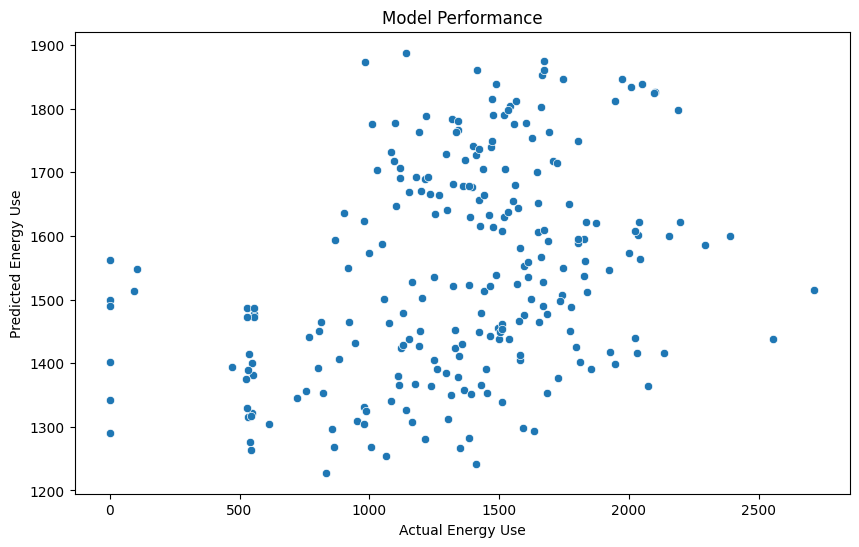

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Test the model
y_pred = model.predict(x_test)
print("Model testing completed")

# Evaluate the results using mean MSE, MAE and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print results
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# Visualise the results
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
results_df = results_df.reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x="Actual", y="Predicted")
plt.xlabel("Actual Energy Use")
plt.ylabel("Predicted Energy Use")
plt.title("Model Performance")
plt.show()